In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
#for traing model
from sklearn.linear_model import LinearRegression
#for spliting data
from sklearn.model_selection import train_test_split


In [49]:
df =pd.read_csv("HousePricePrediction.csv")
# ct=df.dropna()
# ct.isnull()
df

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2914,160,RM,1936,Inside,Twnhs,7,1970,1970,CemntBd,0.0,546.0,NaN
2915,2915,160,RM,1894,Inside,TwnhsE,5,1970,1970,CemntBd,0.0,546.0,NaN
2916,2916,20,RL,20000,Inside,1Fam,7,1960,1996,VinylSd,0.0,1224.0,NaN
2917,2917,85,RL,10441,Inside,1Fam,5,1992,1992,HdBoard,0.0,912.0,NaN


In [50]:
# Data Preprocessing - Data cleaning

# Drop Id as it doesn't contribute in price
df.drop(['Id'],axis=1,inplace=True)

# Replacing SalePrice empty values with their mean values
df['SalePrice'] = df['SalePrice'].fillna(
  df['SalePrice'].mean()) 

# Drop records with null values
df = df.dropna()

df.isnull().sum()
df.head()

,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


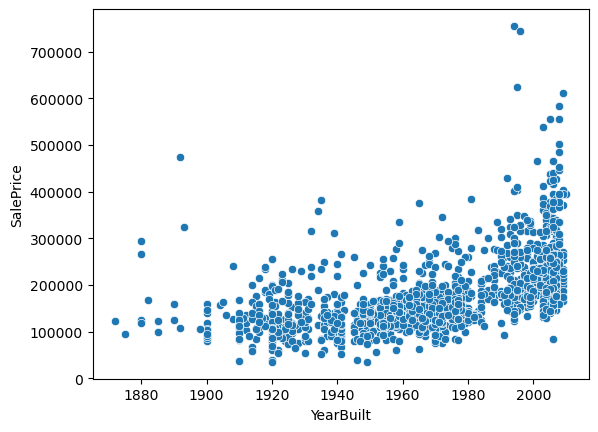

In [118]:
ploting=sns.scatterplot(x=df["YearBuilt"],y=df["SalePrice"])

In [150]:
# x=df.drop(columns=["Id","Exterior1st","BldgType","SalePrice"], axis=1)
# y=df["SalePrice"]


In [151]:
# x["MSZoning"]=x["MSZoning"].map({"C (all)": 0,"RL": 1,"RM":2,"FV":3,"RH":4})
# x["LotConfig"]=x["LotConfig"].map({"FR3":0,"Inside":1,"FR2":2,"Corner":3,"CulDSac":4})
# x["BldgType"]=x["BldgType"].map({"1Fam":0,"I2fmCon":1,"Duplex":2,"Twnhs":3,"TwnhsE":4})

In [51]:
cols = ['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']
df = pd.get_dummies(df, columns=cols, drop_first=True)

In [52]:
x = df.drop(['SalePrice'], axis=1)
y = df['SalePrice']

In [53]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=0)
x_train

,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,MSZoning_FV,MSZoning_RH,MSZoning_RL,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
1453,20,17217,5,2006,2006,0.0,1140.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2021,20,19508,5,1974,1974,0.0,1430.0,False,False,True,...,False,True,False,False,False,False,False,False,False,False
188,90,7018,5,1979,1979,0.0,1086.0,False,False,True,...,False,False,False,False,True,False,False,False,False,False
1273,80,11512,7,1959,2006,0.0,1019.0,False,False,True,...,False,False,False,False,True,False,False,False,False,False
1960,20,7560,5,1971,1971,613.0,864.0,False,False,True,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,60,9430,5,1999,1999,0.0,1252.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
835,20,9600,7,1950,1995,0.0,1067.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1653,160,2308,5,1976,1976,0.0,804.0,False,False,True,...,False,False,False,False,True,False,False,False,False,False
2612,20,11625,7,1983,1983,0.0,816.0,False,False,True,...,False,True,False,False,False,False,False,False,False,False


In [24]:
# print(x_train.isnull().any())
# print(x_train.isnull().sum())

In [54]:
model=LinearRegression()

In [55]:
model.fit(x_train, y_train)

LinearRegression()

In [56]:
y_pred=model.predict(x_test)


In [57]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

In [58]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print(mean_absolute_percentage_error(y_test, y_pred))


R2 Score: 0.37414217961383023
MAE: 30829.93666432242
RMSE: 41138.55870230181
0.18742025463428405


In [59]:
# Feature Scaling - to try & improve baseline performance
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print(mean_absolute_percentage_error(y_test, y_pred))

# To get better results we can try some other regression model 
# & also use techniques like Bagging & Boosting (will cover later).

R2 Score: 0.3741421796138532
MAE: 30829.936664321864
RMSE: 41138.55870230105
0.187420254634278
